<a href="https://colab.research.google.com/github/paocamacho06-jpg/Simulacion-ll/blob/main/Modelo_SIR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Peoyecto ajuste de parametros del modelo SIR


*   Graficar los datos
*   Programar la solucion numerica del modelo SIR con parametros libres
*   Plantear un ajuste por minimos cuadrados.X (a,b)
*   Usar el metodo MCMC (Metropolis - Hastings) para optimizar X
*   Replantear con pyMC en el enfoque bayesiano







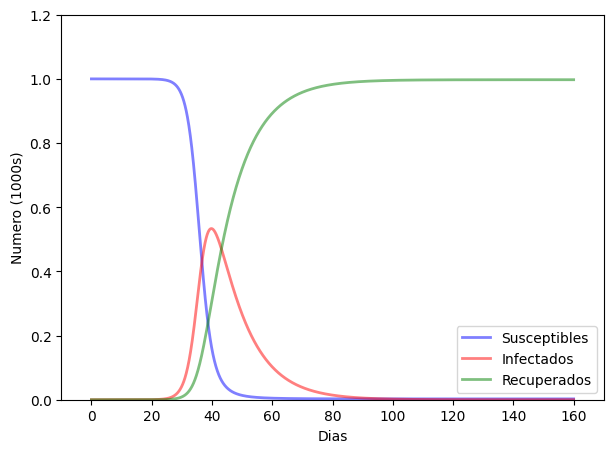

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
# --------------------------------------------------
# Sistema SIR
# --------------------------------------------------

def modelo_SIR(t, y, a, b):

    S, I, R = y

    dSdt = -a * S * I
    dIdt = a * S * I - b * I
    dRdt = b * I

    return [dSdt, dIdt, dRdt]

a = 0.5993
b = 0.1003

I0 = 1.42e-8
S0 = 1 - I0
R0 = 0

y0 = [S0, I0, R0]

t = np.linspace(0, 160, 2000)

solucion = solve_ivp(
    modelo_SIR,
    [0, 160],
    y0,
    args=(a, b),
    t_eval=t,
    rtol=1e-10,
    atol=1e-12
)

S = solucion.y[0]
I = solucion.y[1]
R = solucion.y[2]

plt.figure(figsize=(7, 5))

plt.plot(t, S, color="blue", linewidth=2, alpha=0.5,
         label="Susceptibles")

plt.plot(t, I, color="red", linewidth=2, alpha=0.5,
         label="Infectados")

plt.plot(t, R, color="green", linewidth=2, alpha=0.5,
         label="Recuperados")


plt.xlabel("Dias")
plt.ylabel("Numero (1000s)")

plt.xlim(-10, 170)
plt.ylim(0, 1.2)

plt.xticks(np.arange(0, 161, 20))
plt.yticks(np.arange(0, 1.21, 0.2))

plt.legend(loc="lower right")

plt.show()

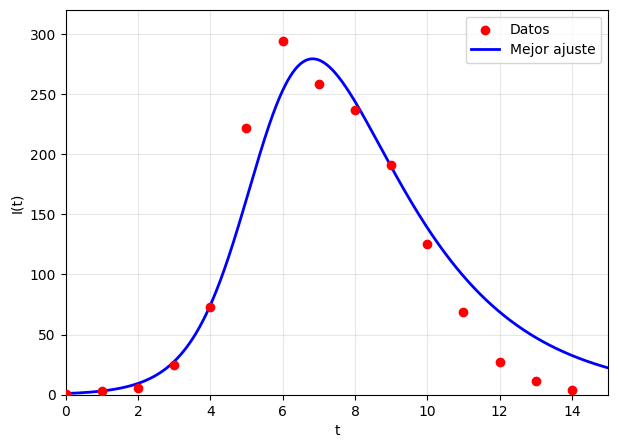

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

t_datos = np.arange(0, 15)

I_datos = np.array([
    1, 3, 6, 25, 73,
    222, 294, 258, 237,
    191, 125, 69, 27, 11, 4
])

a = 0.00205
b = 0.43552

N = 763

I0 = 1
R0 = 0
S0 = N - I0 - R0

y0 = [S0, I0, R0]

def modelo_SIR(t, y, a, b):

    S, I, R = y

    dSdt = -a * S * I
    dIdt = a * S * I - b * I
    dRdt = b * I

    return [dSdt, dIdt, dRdt]

t = np.linspace(0, 15, 1000)

solucion = solve_ivp(
    modelo_SIR,
    [0, 15],
    y0,
    args=(a, b),
    t_eval=t,
    rtol=1e-9,
    atol=1e-9
)


# Infectados obtenidos por el modelo
I_modelo = solucion.y[1]

plt.figure(figsize=(7, 5))

# Datos experimentales
plt.scatter(
    t_datos,
    I_datos,
    color="red",
    label="Datos",
    zorder=3
)

# Mejor ajuste del modelo SIR
plt.plot(
    t,
    I_modelo,
    color="blue",
    linewidth=2,
    label="Mejor ajuste"
)

plt.xlabel("t")
plt.ylabel("I(t)")

plt.xlim(0, 15)
plt.ylim(0, 320)

plt.xticks(np.arange(0, 16, 2))
plt.yticks(np.arange(0, 301, 50))

plt.legend()

plt.grid(alpha=0.3)

plt.show()

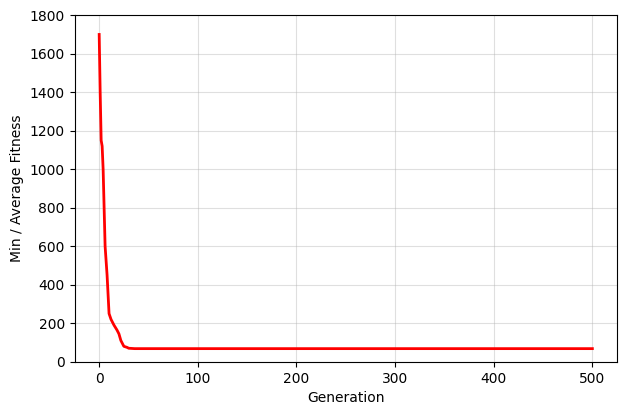

In [13]:

import numpy as np
import matplotlib.pyplot as plt


# Generaciones mostradas en el artículo
generacion = np.arange(0, 501)


# Puntos aproximados obtenidos de la Figura 5
g = np.array([
    0, 1, 2, 3, 4, 5, 6, 8,
    10, 12, 15, 18, 20, 22,
    25, 28, 30, 35, 40, 50, 500
])

fitness = np.array([
    1700, 1400, 1150, 1120, 1000, 800, 600, 450,
    250, 220, 190, 165, 145, 110,
    80, 75, 70, 68, 68, 68, 68
])


# Interpolación para obtener la curva completa
fitness_min = np.interp(generacion, g, fitness)


# --------------------------------------------------
# GRÁFICA
# --------------------------------------------------

plt.figure(figsize=(7, 4.5))

plt.plot(
    generacion,
    fitness_min,
    color="red",
    linewidth=2
)

plt.xlabel("Generation")
plt.ylabel("Min / Average Fitness")

plt.xlim(-25, 525)
plt.ylim(0, 1800)

plt.xticks(np.arange(0, 501, 100))
plt.yticks(np.arange(0, 1801, 200))

plt.grid(True, alpha=0.4)

plt.show()